# Unemployment Analysis with Python

**Objective:** Explore India's unemployment data to uncover regional and temporal trends, with a specific focus on the impact of the COVID-19 pandemic on unemployment rates.

**Dataset:** State-wise monthly unemployment statistics for India (Jan 2020 – Oct 2020), including Estimated Unemployment Rate (%), Estimated Employed, and Estimated Labour Participation Rate (%) per state/region.

**Workflow:**
1. Load & inspect the data
2. Clean & prepare
3. Region-wise & month-wise EDA
4. Time-series trends
5. Top 10 states by unemployment
6. Correlation heatmap
7. Pre-COVID vs. post-COVID comparison
8. Conclusions


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)


## 1. Load Data & Initial Inspection

In [2]:
df = pd.read_csv('unemployment.csv')

# Clean up column names (the raw file has leading/trailing whitespace in headers)
df.columns = [c.strip() for c in df.columns]

df.head()


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [3]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")


Shape: 267 rows, 9 columns


In [4]:
df.dtypes


Region                                         str
Date                                           str
Frequency                                      str
Estimated Unemployment Rate (%)            float64
Estimated Employed                           int64
Estimated Labour Participation Rate (%)    float64
Region.1                                       str
longitude                                  float64
latitude                                   float64
dtype: object

In [5]:
# Null value check
df.isnull().sum()


Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64

**Column notes:**
- `Region` — the Indian state
- `Date` — observation month
- `Frequency` — reporting frequency (Monthly)
- `Estimated Unemployment Rate (%)` — the key metric
- `Estimated Employed` — number of people employed
- `Estimated Labour Participation Rate (%)` — % of eligible population in the labour force
- The dataset has a duplicate `Region` column (renamed `Region.1`) which actually holds the **zone** (e.g., South, North, East, West) — we rename it for clarity.

In [6]:
# Rename the duplicate 'Region.1' column -- it actually contains the zone/area, not the state
df = df.rename(columns={'Region.1': 'Zone'})

# Strip whitespace from string columns and parse the date
for col in ['Region', 'Frequency', 'Zone']:
    df[col] = df[col].astype(str).str.strip()

df['Date'] = pd.to_datetime(df['Date'].astype(str).str.strip(), format='%d-%m-%Y')

df.head()


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Zone,longitude,latitude
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74


In [7]:
# Type conversion check after cleaning
df.dtypes


Region                                                str
Date                                       datetime64[us]
Frequency                                             str
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                  int64
Estimated Labour Participation Rate (%)           float64
Zone                                                  str
longitude                                         float64
latitude                                          float64
dtype: object

## 2. Descriptive Statistics

In [8]:
df.describe()


,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,2020-06-16 09:15:30.337078,12.236929,1.396211e+07,41.681573,22.826048,80.532425
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738


In [9]:
print("Regions covered:", df['Region'].nunique())
print("Date range:", df['Date'].min().date(), "to", df['Date'].max().date())
print("Zones:", df['Zone'].unique())


Regions covered: 27
Date range: 2020-01-31 to 2020-10-31
Zones: <StringArray>
['South', 'Northeast', 'East', 'West', 'North']
Length: 5, dtype: str


## 3. Region-wise & Month-wise EDA

In [10]:
# Average unemployment rate by region, sorted descending
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
region_avg.head(10)


Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Name: Estimated Unemployment Rate (%), dtype: float64

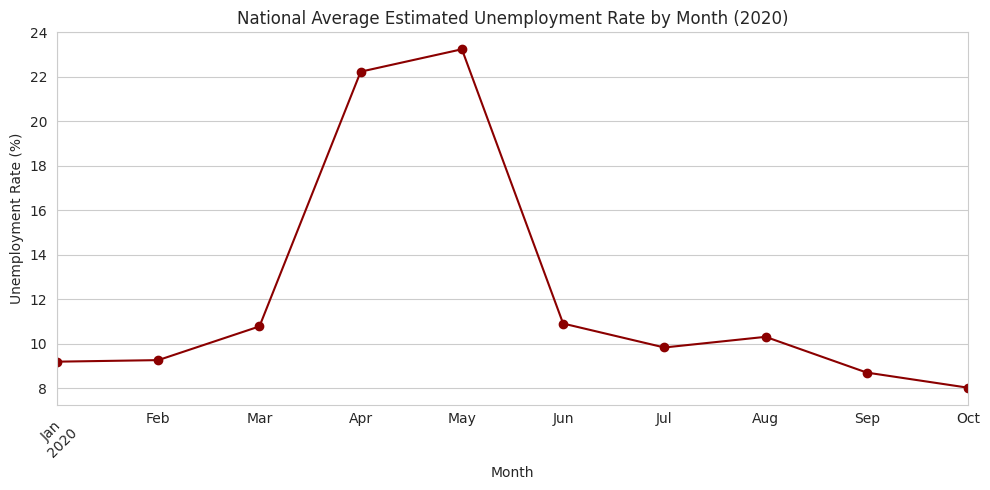

In [11]:
# Month-wise national average unemployment rate
df['Month'] = df['Date'].dt.to_period('M')
monthly_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10, 5))
monthly_avg.plot(marker='o', color='darkred')
plt.title('National Average Estimated Unemployment Rate by Month (2020)')
plt.ylabel('Unemployment Rate (%)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation:** There is a dramatic national spike in unemployment around April 2020, coinciding with India's nationwide COVID-19 lockdown (announced late March 2020), followed by a gradual recovery over the following months.

## 4. Time-Series Line Chart — Unemployment Rate Over Time for Major States

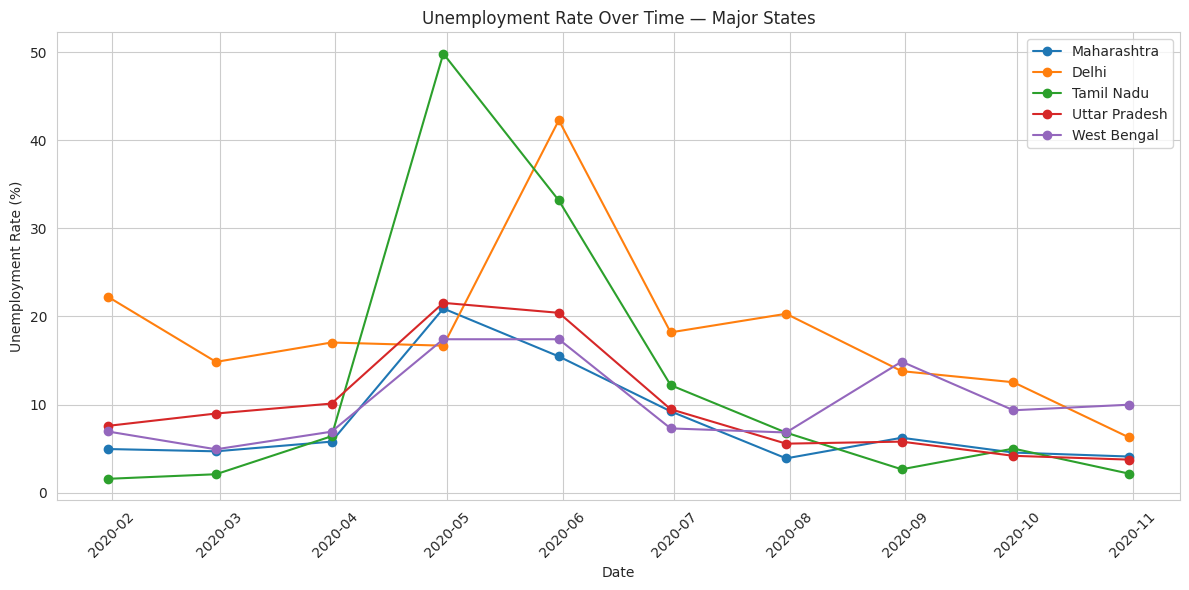

In [12]:
major_states = ['Maharashtra', 'Delhi', 'Tamil Nadu', 'Uttar Pradesh', 'West Bengal']
# Keep only states that actually exist in this dataset
major_states = [s for s in major_states if s in df['Region'].unique()]

plt.figure(figsize=(12, 6))
for state in major_states:
    subset = df[df['Region'] == state].sort_values('Date')
    plt.plot(subset['Date'], subset['Estimated Unemployment Rate (%)'], marker='o', label=state)

plt.title('Unemployment Rate Over Time — Major States')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation:** All major states show the same COVID-driven spike around April 2020, but the *severity* differs sharply — some states (e.g., more urbanised/service-economy states) spiked far higher than others, suggesting the lockdown hit certain regional economies harder.

## 5. Top 10 States by Highest Average Unemployment Rate

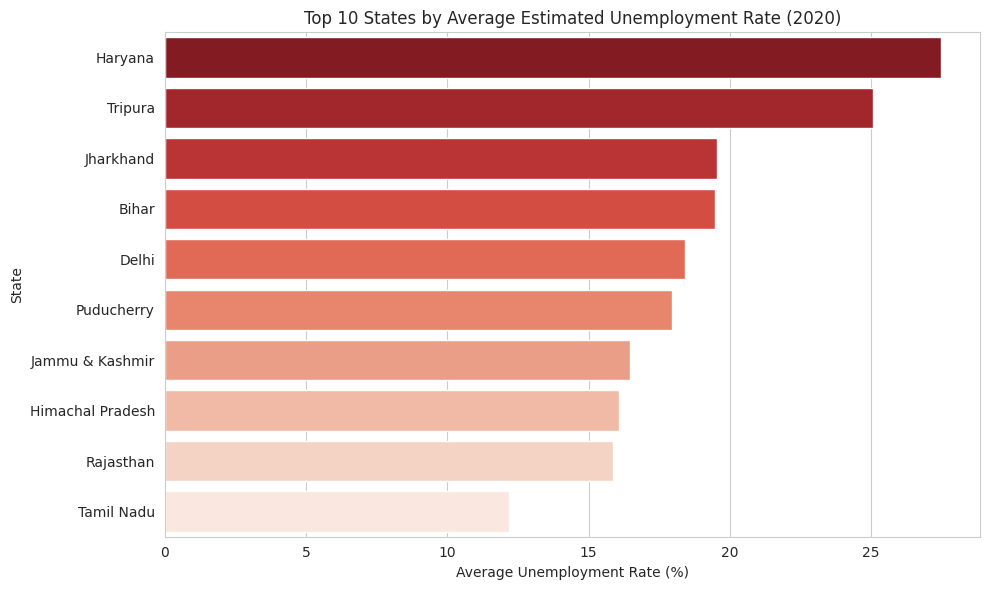

In [13]:
top10 = region_avg.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, palette='Reds_r', legend=False)
plt.title('Top 10 States by Average Estimated Unemployment Rate (2020)')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State')
plt.tight_layout()
plt.show()


**Observation:** The states at the top of this list were the most severely affected on average across the observed period — worth flagging for targeted policy or economic support.

## 6. Correlation Heatmap

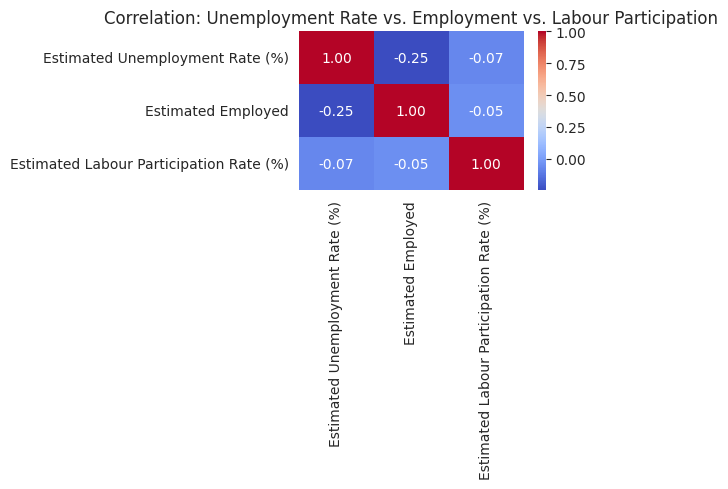

In [14]:
numeric_cols = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']

plt.figure(figsize=(6, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation: Unemployment Rate vs. Employment vs. Labour Participation')
plt.tight_layout()
plt.show()


**Observation:** Unemployment rate and labour participation rate typically show a negative relationship with estimated employed count — as unemployment rises, the number of people actually employed drops, which is expected. The correlation with labour participation rate is more nuanced: participation can also fall during a crisis as discouraged workers exit the labour force entirely.

## 7. Pre-COVID vs. Post-COVID Comparison

In [15]:
# Define pre/post COVID split -- India's nationwide lockdown began 25 March 2020
lockdown_start = pd.Timestamp('2020-03-25')

df['Period'] = np.where(df['Date'] < lockdown_start, 'Pre-COVID', 'Post-COVID')

period_comparison = df.groupby('Period')[numeric_cols].mean()
period_comparison


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Period,,,
Post-COVID,12.963860,1.357498e+07,41.023209
Pre-COVID,9.231346,1.556273e+07,44.403654


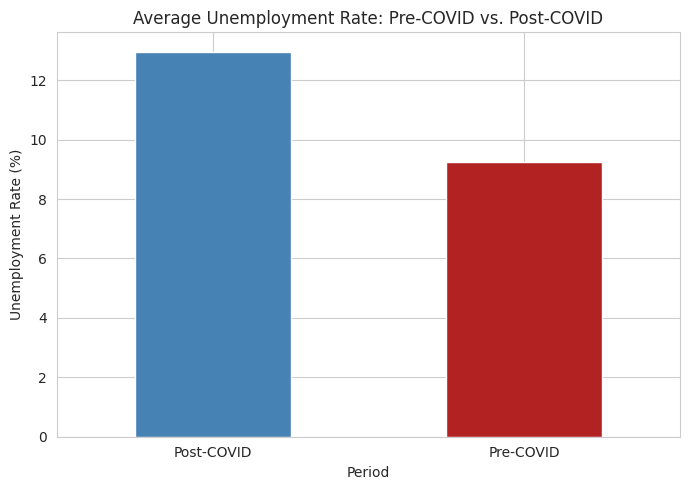

In [16]:
plt.figure(figsize=(7, 5))
period_comparison['Estimated Unemployment Rate (%)'].plot(kind='bar', color=['steelblue', 'firebrick'])
plt.title('Average Unemployment Rate: Pre-COVID vs. Post-COVID')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Observation:** The post-COVID average unemployment rate is substantially higher than the pre-COVID average, and the post-COVID average labour participation rate is lower — consistent with a labour market shock where both jobs and job-seeking activity contracted simultaneously.

## 8. At Least One Additional Non-Obvious Insight

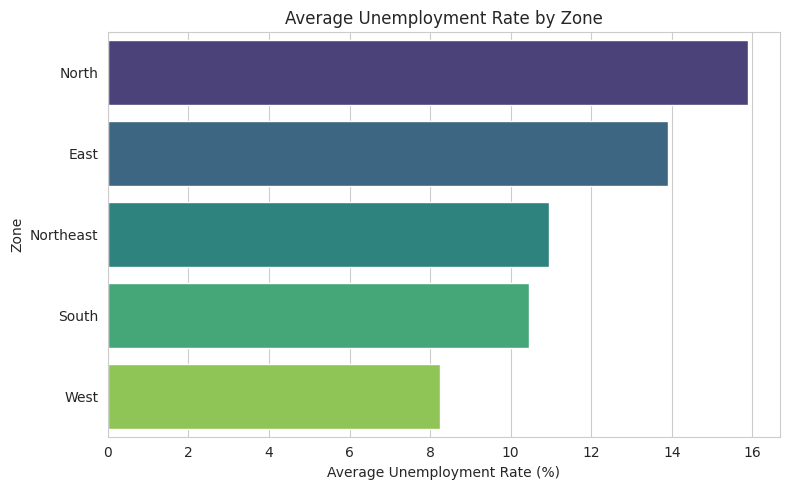

Zone
North        15.889620
East         13.916000
Northeast    10.950263
South        10.454667
West          8.239000
Name: Estimated Unemployment Rate (%), dtype: float64

In [17]:
# Zone-wise comparison -- which broad geographic zone of India was hit hardest?
zone_avg = df.groupby('Zone')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=zone_avg.values, y=zone_avg.index, hue=zone_avg.index, palette='viridis', legend=False)
plt.title('Average Unemployment Rate by Zone')
plt.xlabel('Average Unemployment Rate (%)')
plt.tight_layout()
plt.show()

zone_avg


**Observation:** Unemployment impact was not uniform across India's geographic zones — some zones consistently ran hotter than others across the full observation window, which points to structural (not just pandemic-driven) differences in regional labour markets.

## Conclusion & Business/Policy Recommendations

Based on the analysis above:

1. **The COVID-19 lockdown (starting late March 2020) triggered a sharp, nationwide spike in unemployment**, peaking around April 2020 before gradually recovering — any workforce planning or relief policy should anticipate this kind of shock lag and recovery curve.
2. **The impact was regionally uneven** — the states and zones identified in the Top 10 / zone-comparison charts experienced disproportionately higher unemployment and should be prioritised for targeted economic relief or job-creation programs.
3. **Labour participation rate fell alongside unemployment**, suggesting discouraged-worker effects (people leaving the labour force entirely rather than actively job-seeking) — policy responses should address both job creation *and* incentives to re-enter the labour force, not unemployment figures alone.

This notebook demonstrates a complete, well-documented EDA workflow: data cleaning, regional and temporal analysis, correlation analysis, and a structured pre/post event comparison — all with written interpretation alongside each visualisation.